# Parkinsons Telemonitoring: k-Nearest Neighbors Regression

The [Parkinsons Telemonitoring dataset](https://doi.org/10.24432/C5ZS3N) (Tsanas & Little, 2009, UCI Machine Learning Repository) contains 5,875 home voice recordings from 42 people with early-stage Parkinson's disease during a six-month study. This analysis uses the 16 voice measurements to predict motor and total Unified Parkinson's Disease Rating Scale (UPDRS) scores with separate k-nearest neighbors (k-NN) regression models. The UPDRS scores were linearly interpolated, so each recording does not represent a separate clinical assessment.

In [1]:
import pandas as pd

# parkinsons_updrs.data is in CSV format despite the file extension
df = pd.read_csv("data/parkinsons_updrs.data")
df.shape

(5875, 22)

In [2]:
# Count participants separately because each person has multiple recordings.
df.info()
print("distinct participants:", df["subject#"].nunique())
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 5875 entries, 0 to 5874
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   subject#       5875 non-null   int64  
 1   age            5875 non-null   int64  
 2   sex            5875 non-null   int64  
 3   test_time      5875 non-null   float64
 4   motor_UPDRS    5875 non-null   float64
 5   total_UPDRS    5875 non-null   float64
 6   Jitter(%)      5875 non-null   float64
 7   Jitter(Abs)    5875 non-null   float64
 8   Jitter:RAP     5875 non-null   float64
 9   Jitter:PPQ5    5875 non-null   float64
 10  Jitter:DDP     5875 non-null   float64
 11  Shimmer        5875 non-null   float64
 12  Shimmer(dB)    5875 non-null   float64
 13  Shimmer:APQ3   5875 non-null   float64
 14  Shimmer:APQ5   5875 non-null   float64
 15  Shimmer:APQ11  5875 non-null   float64
 16  Shimmer:DDA    5875 non-null   float64
 17  NHR            5875 non-null   float64
 18  HNR            5875

,subject#,age,sex,test_time,motor_UPDRS,total_UPDRS,Jitter(%),Jitter(Abs),Jitter:RAP,Jitter:PPQ5,...,Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,Shimmer:APQ11,Shimmer:DDA,NHR,HNR,RPDE,DFA,PPE
0,1,72,0,5.6431,28.199,34.398,0.00662,0.000034,0.00401,0.00317,...,0.230,0.01438,0.01309,0.01662,0.04314,0.014290,21.640,0.41888,0.54842,0.16006
1,1,72,0,12.6660,28.447,34.894,0.00300,0.000017,0.00132,0.00150,...,0.179,0.00994,0.01072,0.01689,0.02982,0.011112,27.183,0.43493,0.56477,0.10810
2,1,72,0,19.6810,28.695,35.389,0.00481,0.000025,0.00205,0.00208,...,0.181,0.00734,0.00844,0.01458,0.02202,0.020220,23.047,0.46222,0.54405,0.21014
3,1,72,0,25.6470,28.905,35.810,0.00528,0.000027,0.00191,0.00264,...,0.327,0.01106,0.01265,0.01963,0.03317,0.027837,24.445,0.48730,0.57794,0.33277
4,1,72,0,33.6420,29.187,36.375,0.00335,0.000020,0.00093,0.00130,...,0.176,0.00679,0.00929,0.01819,0.02036,0.011625,26.126,0.47188,0.56122,0.19361


In [3]:
# Check for missing values and duplicates without removing any rows.
# For manual comparison, .names lists 26 columns and about 200 recordings per person.
recordings_per_participant = df.groupby("subject#").size()
pd.Series({
    "recordings": len(df),
    "columns": df.shape[1],
    "participants": df["subject#"].nunique(),
    "missing values": int(df.isna().sum().sum()),
    "duplicate rows": int(df.duplicated().sum()),
    "fewest recordings per participant": recordings_per_participant.min(),
    "most recordings per participant": recordings_per_participant.max(),
    # The 12 negative times do not affect the model because test_time is excluded.
    "negative test_time values": int((df["test_time"] < 0).sum()),
}, name="count").to_frame()

,count
recordings,5875
columns,22
participants,42
missing values,0
duplicate rows,0
fewest recordings per participant,101
most recordings per participant,168
negative test_time values,12


## Why k-NN Regression?

k-NN predicts a score by finding the k closest training recordings and averaging their UPDRS scores. This model gives each neighbor equal weight:

$$
\hat{y}(\mathbf{x}) = \frac{1}{k}\sum_{i \in N_k(\mathbf{x})} y_i.
$$

Here, $N_k(\mathbf{x})$ is the set of k nearest training recordings to the recording being predicted, and $y_i$ is a neighbor's observed score. Closeness is measured by Euclidean distance using the 16 standardized voice measurements. Each outcome has its own predicted average.

This method can capture nonlinear relationships without specifying a particular equation relating voice measurements to UPDRS. It assumes recordings with similar voice measurements tend to have similar scores. A small k uses a very local average and is sensitive to individual recordings. A larger k smooths predictions over more recordings but can miss local differences.

In [4]:
import numpy as np

# Use the same settings for both outcomes.
TARGETS = ["motor_UPDRS", "total_UPDRS"]
# Try small and large neighborhoods to examine overfitting and underfitting.
NEIGHBOR_GRID = [1, 2, 3, 5, 7, 11, 15, 21, 31, 51, 101, 201, 501, 1001]
TEST_SIZE = 0.2
N_FOLDS = 5
RANDOM_STATE = 33

In [5]:
from sklearn.model_selection import train_test_split

# Use the same 80/20 split for both outcomes, with a fixed seed for reproducibility.
train_idx, test_idx = train_test_split(
    df.index, test_size=TEST_SIZE, random_state=RANDOM_STATE
)
# Check participant overlap, which limits what we can conclude about new people.
train_participants = set(df.loc[train_idx, "subject#"])
test_participants = set(df.loc[test_idx, "subject#"])
print("Training recordings:", len(train_idx))
print("Test recordings:", len(test_idx))
print("Participants in both sets:", len(train_participants & test_participants))

Training recordings: 4700
Test recordings: 1175
Participants in both sets: 42


In [6]:
# Keep the voice measurements and exclude ID, demographics, time, and both UPDRS scores.
feature_cols = list(df.columns[6:])
assert len(feature_cols) == 16
feature_cols

['Jitter(%)',
 'Jitter(Abs)',
 'Jitter:RAP',
 'Jitter:PPQ5',
 'Jitter:DDP',
 'Shimmer',
 'Shimmer(dB)',
 'Shimmer:APQ3',
 'Shimmer:APQ5',
 'Shimmer:APQ11',
 'Shimmer:DDA',
 'NHR',
 'HNR',
 'RPDE',
 'DFA',
 'PPE']

In [7]:
# Calculate absolute Pearson correlations using only the training recordings.
correlations = df.loc[train_idx, feature_cols].corr().abs()
# Use the upper triangle to exclude self-correlations and repeated pairs.
upper_triangle = np.triu(np.ones(correlations.shape, dtype=bool), k=1)
# Turn the retained pairs into a list, sort by strength, and show the top six.
strongest_correlations = (
    correlations.where(upper_triangle)
    .stack()
    .sort_values(ascending=False)
    .head(6)
    .rename("absolute correlation")
)
# Correlated measurements can give similar voice properties extra weight in distances.
strongest_correlations.to_frame().round(4)

absolute correlation
Shimmer:APQ3 Shimmer:DDA                 1.0000
Jitter:RAP   Jitter:DDP                  1.0000
Shimmer      Shimmer(dB)                 0.9920
             Shimmer:APQ5                0.9850
Jitter(%)    Jitter:DDP                  0.9835
             Jitter:RAP                  0.9835

## Fitting and Evaluating the Models

Each outcome was modeled separately using k-NN regression. The predictors were standardized before fitting the model because k-NN is based on distance. Five-fold cross-validation was used to choose the best value of k based on validation R-squared. The final model was then tested on the holdout set. R-squared measures how well the model explains variation in UPDRS scores, while RMSE and MAE measure prediction error in UPDRS points. Lower RMSE and MAE values indicate better predictions.

In [8]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

results = {}
metric_rows = []
# Fit each outcome separately.
for target in TARGETS:
    y_train = df.loc[train_idx, target]
    y_test = df.loc[test_idx, target]

    # Standardize within each training fold so validation rows do not affect scaling.
    pipe = Pipeline([
        ("scale", StandardScaler()),
        ("knn", KNeighborsRegressor(weights="uniform", metric="euclidean")),
    ])
    # Choose k using five-fold validation R-squared and save training scores for comparison.
    search = GridSearchCV(
        pipe,
        {"knn__n_neighbors": NEIGHBOR_GRID},
        cv=N_FOLDS,
        scoring="r2",
        return_train_score=True,
    )
    # Refit the best pipeline on all training rows before predicting the holdout scores.
    search.fit(df.loc[train_idx, feature_cols], y_train)
    pred = search.predict(df.loc[test_idx, feature_cols])

    # Use the training mean as a baseline without using test outcomes.
    mean_pred = np.full(len(y_test), y_train.mean())
    holdout_rmse = root_mean_squared_error(y_test, pred)
    baseline_rmse = root_mean_squared_error(y_test, mean_pred)
    metric_rows.append({
        "outcome": target,
        "best k": search.best_params_["knn__n_neighbors"],
        "best CV R2": search.best_score_,
        "holdout R2": r2_score(y_test, pred),
        "holdout RMSE": holdout_rmse,
        "mean-only RMSE": baseline_rmse,
        "holdout MAE": mean_absolute_error(y_test, pred),
        # A positive reduction means k-NN improves on the training-mean baseline.
        "RMSE reduction (%)": 100 * (baseline_rmse - holdout_rmse) / baseline_rmse,
    })
    results[target] = {"search": search, "y_test": y_test, "pred": pred}

metrics = pd.DataFrame(metric_rows).set_index("outcome")
metrics.round(3)

,best k,best CV R2,holdout R2,holdout RMSE,mean-only RMSE,holdout MAE,RMSE reduction (%)
outcome,,,,,,,
motor_UPDRS,11,0.305,0.336,6.664,8.181,5.234,18.538
total_UPDRS,11,0.321,0.362,8.751,10.964,6.732,20.182


### Holdout Results

Both models selected k = 11. For motor UPDRS, the holdout R-squared was 0.34, while total UPDRS had an R-squared of 0.36. Compared with predicting the training mean, RMSE improved by about 19% for motor UPDRS and 20% for total UPDRS. These results show that k-NN performs better than the mean-only baseline, although a large amount of variation in UPDRS scores is still not explained by the models.

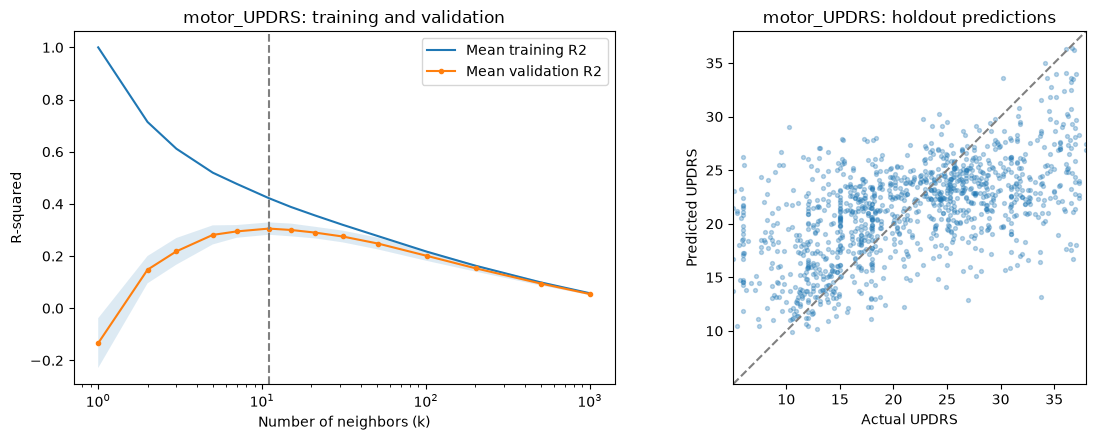

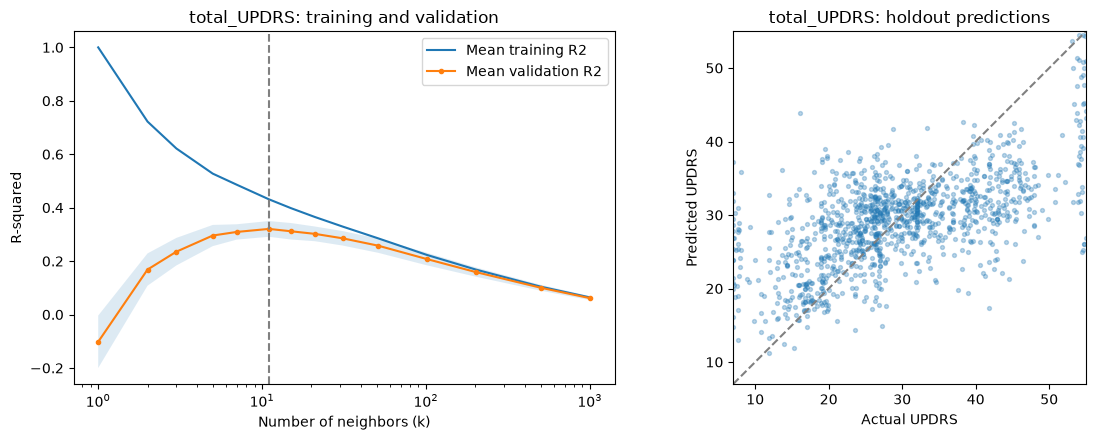

In [9]:
import matplotlib.pyplot as plt

for target, res in results.items():
    search = res["search"]
    neighbor_counts = np.asarray(search.cv_results_["param_knn__n_neighbors"], dtype=int)
    mean_train = search.cv_results_["mean_train_score"]
    mean_cv = search.cv_results_["mean_test_score"]
    std_cv = search.cv_results_["std_test_score"]

    fig, (ax_curve, ax_scatter) = plt.subplots(1, 2, figsize=(12, 4.5))

    # Compare training and validation R-squared across neighborhood sizes.
    ax_curve.plot(neighbor_counts, mean_train, label="Mean training R2")
    ax_curve.plot(neighbor_counts, mean_cv, marker=".", label="Mean validation R2")
    # Shade one standard deviation across folds; this is not a confidence interval.
    ax_curve.fill_between(neighbor_counts, mean_cv - std_cv, mean_cv + std_cv, alpha=0.15)
    ax_curve.set_xscale("log")
    # Mark the selected k with a dashed line.
    ax_curve.axvline(search.best_params_["knn__n_neighbors"], color="gray", linestyle="--")
    ax_curve.set_xlabel("Number of neighbors (k)")
    ax_curve.set_ylabel("R-squared")
    ax_curve.set_title(f"{target}: training and validation")
    ax_curve.legend()

    # Predictions above the diagonal are too high, and those below it are too low.
    ax_scatter.scatter(res["y_test"], res["pred"], s=8, alpha=0.3)
    lims = [
        min(res["y_test"].min(), res["pred"].min()),
        max(res["y_test"].max(), res["pred"].max()),
    ]
    ax_scatter.plot(lims, lims, color="gray", linestyle="--")
    ax_scatter.set_xlim(lims)
    ax_scatter.set_ylim(lims)
    ax_scatter.set_aspect("equal", adjustable="box")
    ax_scatter.set_xlabel("Actual UPDRS")
    ax_scatter.set_ylabel("Predicted UPDRS")
    ax_scatter.set_title(f"{target}: holdout predictions")
    fig.tight_layout()

plt.show()

Predictions generally increase with actual scores, but many points remain far from the diagonal. Low actual scores are often overpredicted, while high scores are often underpredicted. Averaging neighboring recordings tends to pull predictions toward the middle, especially when their scores differ. The models capture part of the relationship but still make substantial errors, likely caused by k-NN averaging the scores of nearby observations.

In [10]:
# Compare cross-validation scores for the small, selected, and large neighborhoods.
tuning_rows = []
for target, res in results.items():
    search = res["search"]
    cv_results = search.cv_results_
    for neighborhood, index in [
        ("small", 0),
        ("selected", search.best_index_),
        ("large", len(NEIGHBOR_GRID) - 1),
    ]:
        train_r2 = cv_results["mean_train_score"][index]
        validation_r2 = cv_results["mean_test_score"][index]
        tuning_rows.append({
            "outcome": target,
            "neighborhood": neighborhood,
            "k": int(cv_results["param_knn__n_neighbors"][index]),
            "mean training R2": train_r2,
            "mean validation R2": validation_r2,
            "training-validation gap": train_r2 - validation_r2,
        })

tuning_comparison = pd.DataFrame(tuning_rows).set_index(["outcome", "neighborhood"])
tuning_comparison.round(4)

k  mean training R2  mean validation R2  \
outcome     neighborhood                                               
motor_UPDRS small            1            1.0000             -0.1337   
            selected        11            0.4219              0.3053   
            large         1001            0.0574              0.0544   
total_UPDRS small            1            1.0000             -0.1020   
            selected        11            0.4314              0.3205   
            large         1001            0.0641              0.0614   

                          training-validation gap  
outcome     neighborhood                           
motor_UPDRS small                          1.1337  
            selected                       0.1166  
            large                          0.0030  
total_UPDRS small                          1.1020  
            selected                       0.1109  
            large                          0.0026

## Bias-Variance Tradeoff

The value of k affects how flexible the model is. At k = 1, the model fits the training data perfectly but performs poorly during cross-validation, which suggests overfitting. At k = 11, validation performance is much better and reaches its highest average value among the tested values of k. Nearby values perform similarly, so k = 11 should not be viewed as the only reasonable choice. At k = 1,001, both training and validation performance are poor because the model averages over too many observations. This shows underfitting.

## Conclusion and limitations

One important limitation is that the same participants appear in both the training and test sets. Because of this, the results show how well the model predicts new recordings from participants it has already seen rather than completely new participants. Participants with more recordings also have more influence on the evaluation metrics. In addition, the UPDRS scores in this dataset are interpolated, and the train-test split does not preserve time order. A future analysis could use participant-based splitting so that entire participants are held out during training and testing.